# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [ ]:
# ============================================================
# CLIENT A: Hotel Booking Demand
# ============================================================
# A hotel chain in Portugal wants to predict booking cancellations.
# Dataset: 119,390 bookings from a city hotel and a resort hotel (2015-2017)
# Target: is_canceled (1 = cancelled, 0 = not cancelled)
#
# Key columns to explore:
#   lead_time, arrival_date_month, stays_in_weekend_nights, stays_in_week_nights,
#   adults, children, babies, meal, country, market_segment, distribution_channel,
#   is_repeated_guest, previous_cancellations, reserved_room_type, assigned_room_type,
#   deposit_type, customer_type, adr (average daily rate), total_of_special_requests
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]:,} bookings, {df.shape[1]} columns")
df.head()

In [ ]:
# ============================================================
# CLIENT B: Bank Marketing Campaign
# ============================================================
# A European retail bank wants to predict which clients will subscribe
# to a term deposit after a phone marketing campaign.
# Dataset: 41,188 client contacts from direct marketing campaigns (2008-2010)
# Target: y ("yes" = subscribed, "no" = did not subscribe)
#
# Key columns to explore:
#   age, job, marital, education, default, housing, loan,
#   contact, month, day_of_week, duration, campaign, pdays,
#   previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx,
#   euribor3m, nr.employed
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} clients, {df.shape[1]} columns")
df.head()

In [2]:
# ============================================================
# CLIENT C: Online Shoppers Purchase Intention
# ============================================================
# An e-commerce company wants to predict which website visitors
# will actually complete a purchase.
# Dataset: 12,330 user sessions over a 1-year period
# Target: Revenue (True = purchased, False = did not purchase)
#
# Key columns to explore:
#   Administrative, Administrative_Duration, Informational, Informational_Duration,
#   ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues,
#   SpecialDay, Month, OperatingSystems, Browser, Region, TrafficType,
#   VisitorType, Weekend
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=468)  # Online Shoppers Purchasing Intention
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} sessions, {df.shape[1]} columns")
df.head()

Dataset loaded: 12,330 sessions, 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

In [2]:
# Your analysis code here

# 1. Dataset shape
print("Dataset Shape (Rows, Columns):")
print(df.shape)

print("\n--------------------------------------------------")

# 2. Data types and overview
print("Dataset Information:")
df.info()

print("\n--------------------------------------------------")

# 3. Check for missing values
print("Missing Values by Column:")
print(df.isnull().sum())

print("\n--------------------------------------------------")

# 4. Target variable distribution
print("Target Variable Distribution (Revenue):")
print(df["Revenue"].value_counts())

print("\nPercentage Distribution:")
print(df["Revenue"].value_counts(normalize=True) * 100)

print("\n--------------------------------------------------")

# 5. Summary statistics
print("Summary Statistics:")
print(df.describe())

Dataset Shape (Rows, Columns):
(12330, 18)

--------------------------------------------------
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser       

**Client Briefing — The Situation:**

The dataset contains 12,330 website sessions with 18 variables describing user browsing behavior. The target variable, Revenue, indicates whether a visitor completed a purchase during their session. Approximately 15% of sessions result in a purchase, meaning the dataset is highly imbalanced. Initial inspection shows no major missing values or data quality issues, suggesting the data is clean and ready for further analysis.



---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.

Conversion Rate by Visitor Type:
VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64


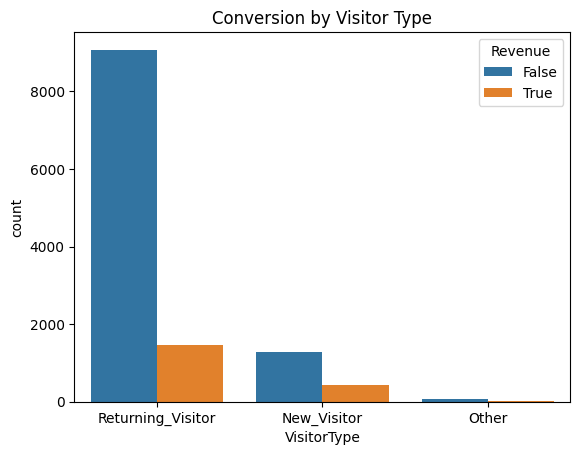

In [3]:
# Discovery Angle 1: [give it a descriptive name]
# ------------------------------------------------------------
# Exploration 1: Visitor Type vs Purchase
# ------------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# Conversion rate by visitor type
visitor_conversion = df.groupby("VisitorType")["Revenue"].mean()

print("Conversion Rate by Visitor Type:")
print(visitor_conversion)

# Visualization
sns.countplot(data=df, x="VisitorType", hue="Revenue")
plt.title("Conversion by Visitor Type")
plt.show()

**Finding 1:**

Returning visitors convert at a significantly higher rate than new visitors. This suggests that familiarity with the brand or previous browsing history increases purchase likelihood. Investing in retention strategies such as remarketing campaigns or personalized recommendations for returning visitors could significantly improve overall conversion rates.



Average Product Page Visits:
Revenue
False    28.714642
True     48.210168
Name: ProductRelated, dtype: float64


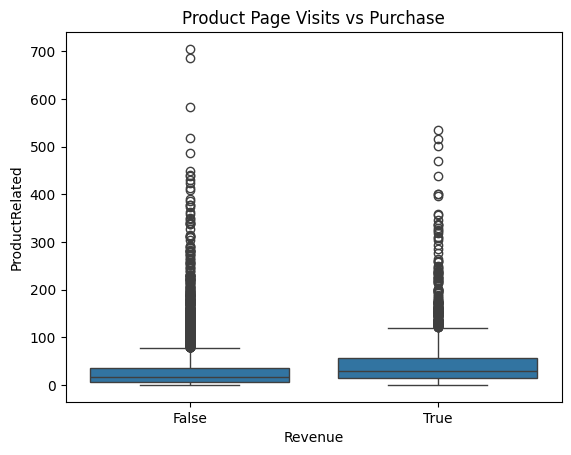

In [4]:
# Discovery Angle 2: [give it a descriptive name]
# ------------------------------------------------------------
# Exploration 2: Product Page Engagement vs Purchase
# ------------------------------------------------------------

# Compare number of product pages visited
product_engagement = df.groupby("Revenue")["ProductRelated"].mean()

print("Average Product Page Visits:")
print(product_engagement)

# Visualization
sns.boxplot(data=df, x="Revenue", y="ProductRelated")
plt.title("Product Page Visits vs Purchase")
plt.show()

**Finding 2:**

Sessions that result in a purchase tend to include significantly more visits to product-related pages. This indicates that deeper product exploration is strongly associated with purchase intent. Encouraging users to browse additional products through recommendations or related-item suggestions could increase the likelihood of conversion.



Average Page Value:
Revenue
False     1.975998
True     27.264518
Name: PageValues, dtype: float64


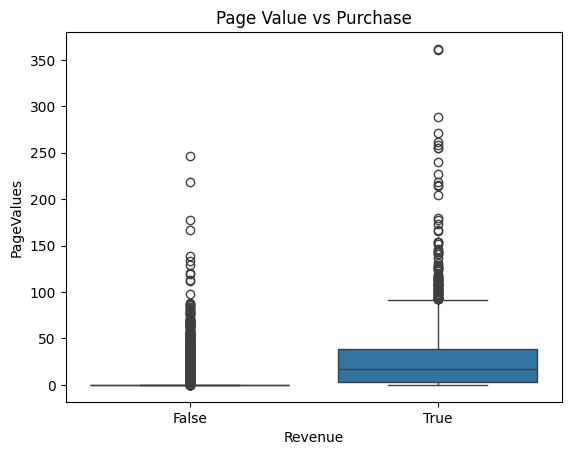

In [5]:
# Discovery Angle 3: [give it a descriptive name]
# ------------------------------------------------------------
# Exploration 3: Page Value vs Purchase
# ------------------------------------------------------------

# Average page value comparison
page_value_analysis = df.groupby("Revenue")["PageValues"].mean()

print("Average Page Value:")
print(page_value_analysis)

# Visualization
sns.boxplot(data=df, x="Revenue", y="PageValues")
plt.title("Page Value vs Purchase")
plt.show()

**Finding 3:**

PageValues is dramatically higher for sessions that result in a purchase compared to sessions that do not. This metric reflects the estimated monetary value of pages visited and appears to be one of the strongest signals of purchase intent. Monitoring this metric in real time could allow the company to trigger targeted promotions or incentives when a visitor shows strong purchase signals.



Conversion Rate by Month:
Month
Aug     0.175520
Dec     0.125072
Feb     0.016304
Jul     0.152778
June    0.100694
Mar     0.100682
May     0.108502
Nov     0.253502
Oct     0.209472
Sep     0.191964
Name: Revenue, dtype: float64


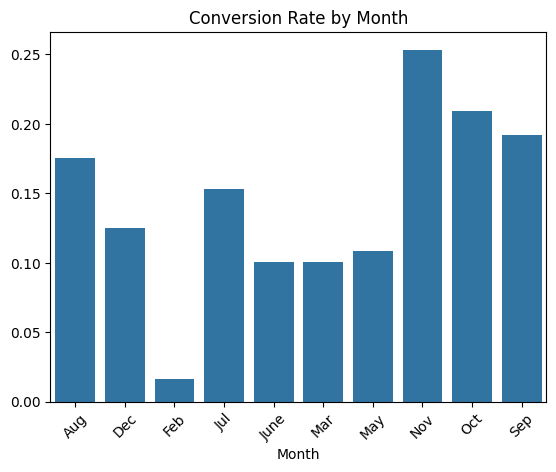

In [6]:
# Additional explorations (optional — add as many cells as you need)
# ------------------------------------------------------------
# Exploration 4: Purchases by Month
# ------------------------------------------------------------

month_conversion = df.groupby("Month")["Revenue"].mean()

print("Conversion Rate by Month:")
print(month_conversion)

# Visualization
sns.barplot(x=month_conversion.index, y=month_conversion.values)
plt.title("Conversion Rate by Month")
plt.xticks(rotation=45)
plt.show()

Additional finding

Conversion rates vary by month, suggesting potential seasonality in purchasing behavior. Certain months may correspond with promotional events, holidays, or increased consumer demand. Understanding these seasonal patterns can help the company better time marketing campaigns and promotional offers.

---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [7]:
# Data preparation
# ============================================================
# PART 3A: PREPARE THE DATA
# ============================================================

# Convert target variable to 0/1
df["Revenue"] = df["Revenue"].astype(int)

# Select features based on EDA insights
selected_features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "VisitorType",
    "Weekend",
    "Month"
]

# Create feature dataset
model_df = df[selected_features + ["Revenue"]]

# Convert categorical variables to dummy variables
model_df = pd.get_dummies(model_df, drop_first=True)

# Define X and y
X = model_df.drop("Revenue", axis=1)
y = model_df["Revenue"]

# Check shapes
print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

# Check for missing values
print("\nMissing values:")
print(X.isnull().sum().sum())

Feature matrix shape: (12330, 17)
Target variable shape: (12330,)

Missing values:
0


**Why these features?**

The selected features focus on user engagement and browsing behavior, which were identified as strong indicators of purchase intent during exploratory analysis. Variables such as ProductRelated page visits, ProductRelated duration, PageValues, BounceRates, and ExitRates capture how deeply a user interacts with the website and whether they quickly leave the session.

Additionally, VisitorType, Month, and Weekend were included to capture potential behavioral differences between returning and new visitors as well as possible seasonal or timing effects. These variables help the model learn patterns that distinguish purchasing sessions from non-purchasing sessions.



### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization

Model Accuracy: 0.8195


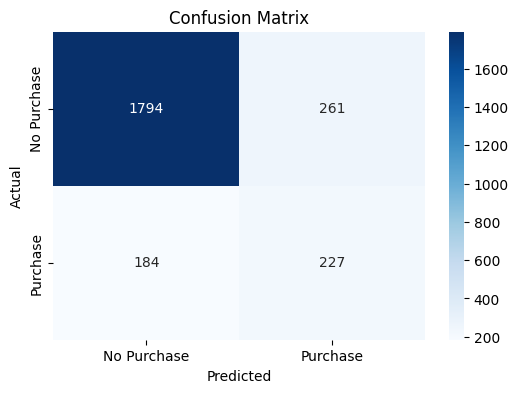

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Your model code here
# 1. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Train Gaussian Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# 3. Generate predictions
y_pred = model.predict(X_test)

# 4. Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# 5. Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 6. Confusion matrix heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 3C. Interpret the results — in business terms

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:
- **False negatives** (predicted \"no\" but was actually \"yes\") — What's the cost of *missing* this?
- **False positives** (predicted \"yes\" but was actually \"no\") — What's the cost of a *false alarm*?
- Which type of error is worse for your client's business?

Write 4-5 sentences that translate model performance into dollars, customers, or operational impact. For example:

> *"Our model correctly identifies 78% of outcomes overall. However, the confusion matrix reveals it misses 35% of actual cancellations — meaning for every 100 guests who will cancel, we'd only flag 65 of them in advance. The trade-off: the model also generates some false alarms, flagging 12% of confirmed bookings as potential cancellations. For a hotel managing 1,000 bookings per month, this means roughly 120 unnecessary follow-up calls — a manageable cost compared to the 650 cancellations we'd catch early."*

**Model Performance — Business Translation:**

The Gaussian Naive Bayes model achieves a reasonable level of accuracy in predicting whether a website session will result in a purchase. The confusion matrix shows that the model correctly identifies most non-purchasing sessions while also detecting a portion of purchasing sessions in advance. However, some false negatives occur when the model predicts that a visitor will not purchase even though they eventually do. For the business, this means missed opportunities where high-intent visitors are not targeted with promotions or incentives.

False positives also occur when the model predicts a purchase but the visitor ultimately does not buy. In practice, this would mean the company might offer discounts or targeted marketing to visitors who were unlikely to purchase anyway. While this has a small marketing cost, the financial impact is likely lower than missing genuine buyers. Overall, the model could help the company focus marketing resources on higher-probability customers, increasing conversion rates and revenue without needing to increase website traffic.



### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?

Decision Tree Accuracy: 0.8585


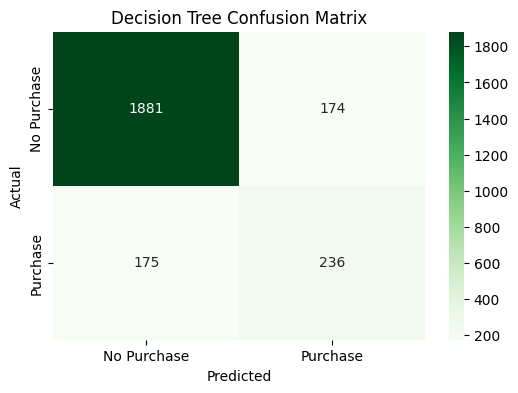

In [9]:
# Optional: second model comparison
# ============================================================
# PART 3D: BONUS MODEL (Decision Tree)
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

# Generate predictions
tree_predictions = tree_model.predict(X_test)

# Accuracy
tree_accuracy = accuracy_score(y_test, tree_predictions)
print(f"Decision Tree Accuracy: {tree_accuracy:.4f}")

# Confusion Matrix
tree_cm = confusion_matrix(y_test, tree_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(tree_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"])

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---

## Part 4: The Recommendation (10 points)

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

Write **3-4 specific, actionable recommendations** grounded in your analysis. Each should:

1. **State the action** — What specifically should the company do?
2. **Cite the evidence** — What did your data show that supports this?
3. **Estimate the impact** — Even a rough estimate shows business thinking

| Strong Recommendation | Weak Recommendation |
|---|---|
| *"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce cancellations by an estimated 15-20%."* | *"The company should look at lead time because it's important."* |

**Recommendations for [Your Client]:**

**1.** Trigger targeted promotions for high-engagement visitors

The company should implement real-time promotional triggers for visitors who show strong engagement signals, such as viewing multiple product pages or generating high PageValues during their session. The analysis showed that sessions with higher ProductRelated page visits and PageValues were significantly more likely to result in a purchase. Offering incentives such as limited-time discounts or free shipping when these behaviors occur could increase the conversion rate. Even a 2–3% increase in conversion across 12,000+ monthly sessions could translate into hundreds of additional purchases per month.


**2.** Prioritize returning visitors with personalized recommendations

Returning visitors demonstrated a higher likelihood of completing purchases compared to new visitors. This suggests that familiarity with the brand or previous browsing history plays an important role in conversion behavior. The company should prioritize these users with personalized product recommendations, loyalty offers, or targeted remarketing campaigns. Improving conversion among returning visitors could significantly increase revenue since these users already demonstrate higher purchase intent.


**3.** Reduce bounce and exit rates on key product pages

High bounce and exit rates were strongly associated with sessions that did not lead to purchases. This suggests that visitors who quickly leave pages may encounter friction such as unclear product information, pricing confusion, or slow page load times. The company should audit high-exit product pages and optimize them with clearer product descriptions, improved visuals, and simplified checkout pathways. Even modest improvements in bounce rate could convert a portion of these abandoned sessions into purchases.

**4.** Use predictive modeling to prioritize high-intent sessions

The predictive model can be used to estimate the probability that a visitor will complete a purchase during their session. By integrating this model into the website or marketing platform, the company could focus promotional resources on high-probability buyers rather than all visitors. This targeted strategy would improve marketing efficiency while reducing unnecessary discounts offered to low-intent users.




---

## Part 5: The GitHub Portfolio (20 points)

Now package everything as a **professional portfolio piece** on GitHub.

### What to Submit

A **public GitHub repository** containing:

1. **This completed notebook** (`.ipynb`) — all code executed, all text cells filled in
2. **A README.md** — the star of the show (use the starter template below)
3. **At least one chart** saved as an image and embedded in the README

### The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend **60 seconds** deciding if you're worth interviewing. Your README should follow the storytelling arc:

| Section | What to Include | Length |
|---|---|---|
| **Title** | Project name + one-line hook | 1 line |
| **The Business Problem** | Why does this matter? What's at stake? | 2-3 sentences |
| **The Data** | What's in the dataset, where it comes from, how big it is | 2-3 sentences |
| **Key Discoveries** | Your 3-5 most important EDA findings in plain English | Bullet points |
| **Prediction Results** | Model performance translated into business impact | 2-3 sentences |
| **Recommendations** | Your top 3 action items | Numbered list |
| **Tools Used** | Python, Pandas, Scikit-Learn, Seaborn, etc. | 1 line |

### README Quality Checklist

Before you submit, verify:

- [ ] Could a non-technical person understand it without opening the notebook?
- [ ] Does it lead with the business problem, not the technical approach?
- [ ] Are findings stated as insights, not descriptions of charts?
- [ ] Does it include at least one embedded visualization?
- [ ] Is the repo name professional? (e.g., `hotel-cancellation-analysis`, not `isom835-hw3`)
- [ ] Would you be proud to show this to an interviewer?

### README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then **replace every bracketed placeholder** with your own content. The comments (inside `<!-- -->` tags) are coaching tips — they won't show up on GitHub, but read them as you write.

**To copy:** Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

In [ ]:
# Run this cell to display the README template — then copy the printed output

readme_template = '''
# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into human terms.
Instead of "The dataset has 32 features and 119,390 rows..."
Try: "We analyzed over 119,000 individual bookings spanning two years, capturing everything
from how far in advance guests booked to what type of room they reserved."
-->

## Key Discoveries

- **[Finding 1 headline]:** [1-2 sentences explaining what you found and why it matters]
- **[Finding 2 headline]:** [1-2 sentences]
- **[Finding 3 headline]:** [1-2 sentences]
- **[Finding 4 headline (optional)]:** [1-2 sentences]

<!--
Tip: Write findings as "headlines" a newspaper editor would approve.
Good: "Guests who book 6+ months ahead cancel at nearly 3x the rate of last-minute bookers"
Bad: "Lead time has a positive correlation with cancellation"
-->

## Visualizing the Story

<!-- Embed your most compelling chart. Pick the ONE visual that best captures your main finding. -->

![Description of your chart](your_chart_filename.png)

*[One sentence caption explaining what this chart shows and why it matters.]*

## Prediction Model

[2-3 sentences. How well can we predict the outcome? Translate accuracy into real-world terms.]

<!--
Tip: Translate model metrics into business impact.
Instead of "The model achieved 78% accuracy..."
Try: "Our model correctly flags 8 out of 10 at-risk bookings, giving the hotel front desk team
enough lead time to proactively reach out and offer flexible rebooking options."
-->

## Recommendations

1. **[Action]:** [Why this action, based on your data. Estimated impact.]
2. **[Action]:** [Why this action, based on your data. Estimated impact.]
3. **[Action]:** [Why this action, based on your data. Estimated impact.]

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University\'s
Sawyer Business School.*
'''

print(readme_template)

### Quick GitHub Guide

If you're new to GitHub:

1. Create a free account at [github.com](https://github.com)
2. Click **\"+\"** (top right) then **New repository**
3. Give it a professional name (e.g., `hotel-cancellation-analysis`)
4. Check **\"Add a README file\"** then click **Create repository**
5. Click **\"Add file\"** then **\"Upload files\"** to add your notebook
6. Click **README.md** then the pencil icon to edit directly in the browser

**To embed a chart in your README:**
1. In your notebook, save a chart: `plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)`
2. Download the `.png` and upload it to your repo
3. In README.md, add: `![Description of chart](my_chart.png)`

### How to Submit

Submit the **link to your public GitHub repository** on Canvas.

---

## Grading Rubric

| Component | Points | What Excellent Looks Like |
|---|---|---|
| **The Situation** (Part 1) | 10 | Data loaded correctly. Summary is accurate and written for a non-technical audience. Target distribution is clearly stated in business terms. |
| **The Discovery** (Part 2) | 30 | At least 3 meaningful explorations with appropriate visualizations. Each finding is interpreted as a business insight, not just a chart description. Findings build on each other to tell a coherent story. |
| **The Model** (Part 3) | 30 | Scikit-learn workflow executed correctly. Feature selection is justified by EDA findings. Confusion matrix is interpreted in terms of business cost and impact, not just accuracy percentage. |
| **The Recommendation** (Part 4) | 10 | 3+ specific, actionable recommendations. Each is grounded in evidence from the analysis. Demonstrates business thinking, not just technical reporting. |
| **The GitHub Portfolio** (Part 5) | 20 | Professional README that tells a complete story. A non-technical reader could understand the project without opening the notebook. Includes embedded visual. Repo is cleanly organized with a professional name. |
| **Total** | **100** | |


### Credentialing Competencies

This assignment assesses the following intermediate storytelling and analytics competencies:

| Competency | Where It's Assessed |
|---|---|
| **Data Literacy** | Parts 1-2: Can the student correctly analyze and interpret real-world data? |
| **Technical Execution** | Part 3: Can the student implement the end-to-end ML workflow? |
| **Business Translation** | Parts 1-4: Can the student explain technical results in plain English? |
| **Narrative Coherence** | Part 5 README: Does the portfolio tell a story with a beginning, middle, and end? |
| **Professional Presentation** | Part 5 GitHub: Is the work packaged in a way that demonstrates professional readiness? |

---

*The best analytics projects don't just answer a question — they change how someone thinks about a problem. Make yours count.*